# Multi-Class Pneumonia Classification using EfficientNet-B0 with Explainable AI (Grad-CAM)

## Notebook 01: Setup and Dataset Verification

### Objectives

- Verify Python and PyTorch environment
- Verify GPU availability
- Verify dataset structure
- Count images in each split
- Visualize sample images
- Prepare the project for model training

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch

print("✅ All required libraries imported successfully.")

✅ All required libraries imported successfully.


## Environment Verification

This section verifies the software environment and hardware configuration required for model development.

In [2]:
# ============================================================
# Environment Information
# ============================================================

import platform
import torch

print("=" * 60)
print("System Information")
print("=" * 60)

print(f"Operating System : {platform.system()} {platform.release()}")
print(f"Python Version   : {platform.python_version()}")
print(f"PyTorch Version  : {torch.__version__}")

print("\nCUDA Available   :", torch.cuda.is_available())

if torch.cuda.is_available():
    print(f"CUDA Version     : {torch.version.cuda}")
    print(f"GPU Name         : {torch.cuda.get_device_name(0)}")
    print(f"GPU Count        : {torch.cuda.device_count()}")

print("=" * 60)

System Information
Operating System : Linux 6.18.33.2-microsoft-standard-WSL2
Python Version   : 3.12.3
PyTorch Version  : 2.13.0+cu126

CUDA Available   : True
CUDA Version     : 12.6
GPU Name         : NVIDIA GeForce RTX 3050
GPU Count        : 1


## Reproducibility

Set a fixed random seed to ensure reproducible experimental results.

In [3]:
# ============================================================
# Set Random Seed
# ============================================================

import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


## Dataset Path Configuration

Define the path to the original chest X-ray dataset.
This dataset will be used for verification before preprocessing.

In [6]:
# ============================================================
# Original Dataset Path
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/mnt/g/Research paper/Research paper/dataset of pneomunia/chest_xray")

print("Dataset Path:")
print(DATASET_DIR)

print(f"\nDataset Exists : {DATASET_DIR.exists()}")

Dataset Path:
/mnt/g/Research paper/Research paper/dataset of pneomunia/chest_xray

Dataset Exists : True


## Dataset Structure Verification

Verify that all required dataset folders are available.

In [7]:
# ============================================================
# Verify Dataset Structure
# ============================================================

required_folders = [
    "train",
    "test",
    "val"
]

print("=" * 60)

for folder in required_folders:
    folder_path = DATASET_DIR / folder

    if folder_path.exists():
        print(f"✅ {folder}")
    else:
        print(f"❌ {folder}")

print("=" * 60)

✅ train
✅ test
✅ val


## Class Verification

Verify that the expected class folders exist in each dataset split.

In [8]:
# ============================================================
# Verify Class Folders
# ============================================================

splits = ["train", "test", "val"]
classes = ["NORMAL", "PNEUMONIA"]

print("=" * 60)

for split in splits:
    print(f"\n{split.upper()}")

    for cls in classes:
        path = DATASET_DIR / split / cls

        if path.exists():
            print(f"  ✅ {cls}")
        else:
            print(f"  ❌ {cls}")

print("\n" + "=" * 60)


TRAIN
  ✅ NORMAL
  ✅ PNEUMONIA

TEST
  ✅ NORMAL
  ✅ PNEUMONIA

VAL
  ✅ NORMAL
  ✅ PNEUMONIA



## Image Count

Count the number of images in each dataset split and class.

In [9]:
# ============================================================
# Count Images in Original Dataset
# ============================================================

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")

splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

image_counts = {}

print("=" * 60)

for split in splits:
    image_counts[split] = {}

    print(f"\n{split.upper()}")

    for cls in classes:

        folder = DATASET_DIR / split / cls

        count = len([
            img for img in folder.iterdir()
            if img.suffix.lower() in IMAGE_EXTENSIONS
        ])

        image_counts[split][cls] = count

        print(f"{cls:<12}: {count}")

print("\n" + "=" * 60)


TRAIN
NORMAL      : 1341
PNEUMONIA   : 3875

VAL
NORMAL      : 8
PNEUMONIA   : 8

TEST
NORMAL      : 234
PNEUMONIA   : 390



## Dataset Summary

Display the total number of images in each dataset split.

In [10]:
# ============================================================
# Dataset Summary
# ============================================================

print("=" * 60)

grand_total = 0

for split in image_counts:

    split_total = sum(image_counts[split].values())

    grand_total += split_total

    print(f"{split.capitalize():<10}: {split_total}")

print("-" * 60)

print(f"Total Images : {grand_total}")

print("=" * 60)

Train     : 5216
Val       : 16
Test      : 624
------------------------------------------------------------
Total Images : 5856


## Dataset Distribution

Visualize the distribution of images across dataset splits.

/tmp/ipykernel_1671/3744097063.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


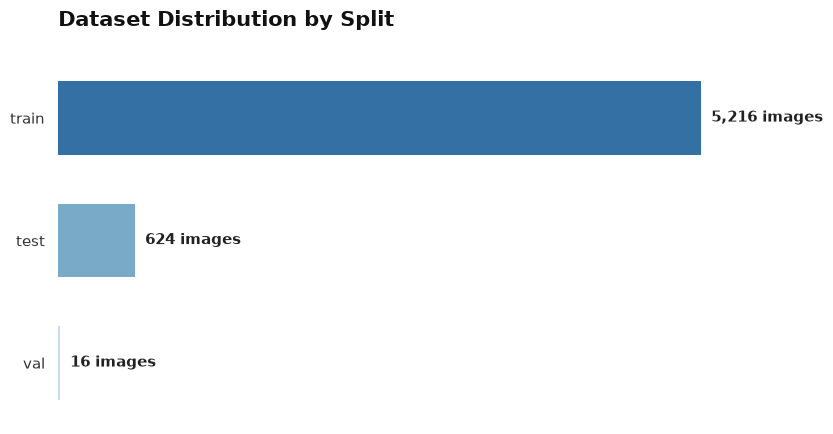

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------
# Data Processing (Converting to DataFrame for Seaborn)
# ------------------------------------------------------------
splits = list(image_counts.keys())
totals = [sum(image_counts[s].values()) for s in splits]

# Create a clean DataFrame (Best practice for modern Seaborn)
df = pd.DataFrame({"Split": splits, "Total Images": totals})
df = df.sort_values(by="Total Images", ascending=False)  # Automatically ranks highest to lowest

# ------------------------------------------------------------
# Theme & Typography Calibration
# ------------------------------------------------------------
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff"
})

# Initialize figure with clean dimensions
fig, ax = plt.subplots(figsize=(8.5, 4.5))

# ------------------------------------------------------------
# Plot Generation (Horizontal Gradient Layout)
# ------------------------------------------------------------
# Using the "Blues_r" gradient palette for a highly polished, aesthetic look
sns.barplot(
    data=df,
    x="Total Images",
    y="Split",
    palette="Blues_r",  # Dark blue for largest, light blue for smallest
    width=0.6,
    edgecolor="none",
    ax=ax
)

# ------------------------------------------------------------
# Modern Aesthetic Styling
# ------------------------------------------------------------
# Minimalist Titles & Labels (X-axis label removed since values are printed directly)
ax.set_title("Dataset Distribution by Split", fontsize=15, pad=22, fontweight="bold", color="#111111", loc="left")
ax.set_xlabel("") 
ax.set_ylabel("", labelpad=15)

# Typography refinement for Y-axis categories
ax.tick_params(axis="y", labelsize=11, colors="#333333", left=False)
ax.set_xticklabels([])  # Removes bottom axis numbers completely for maximum cleanliness
ax.xaxis.grid(False)    # Removes background grid lines completely

# Remove all structural box lines (spines)
sns.despine(left=True, bottom=True)

# ------------------------------------------------------------
# Premium Floating Value Annotations
# ------------------------------------------------------------
# Adds precise formatting on the right edge of each horizontal bar
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt="  {:,.0f} images",  # Formats with commas and adds context text
        label_type="edge", 
        fontsize=10.5,
        fontweight="bold",
        color="#222222"
    )

# ------------------------------------------------------------
# Render
# ------------------------------------------------------------
plt.tight_layout()
plt.show()


## Class Distribution

Visualize the class distribution for each dataset split.

findfont: Failed to find font weight medium, now using 400.


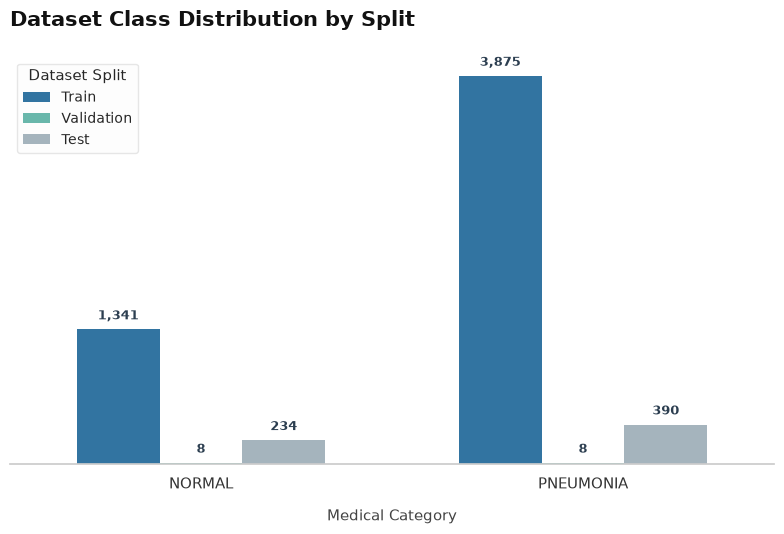

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------
# Data Restructuring (Tidy Format for Modern Seaborn)
# ------------------------------------------------------------
classes = ["NORMAL", "PNEUMONIA"]
splits = ["Train", "Validation", "Test"]

# Build a structured list of rows for the DataFrame
data_rows = []
for split_key, split_label in [("train", "Train"), ("val", "Validation"), ("test", "Test")]:
    for cls in classes:
        count = image_counts[split_key][cls]
        data_rows.append({"Split": split_label, "Class": cls, "Count": count})

df = pd.DataFrame(data_rows)

# ------------------------------------------------------------
# Theme & Typography Calibration
# ------------------------------------------------------------
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "font.family": "sans-serif",
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff"
})

# Initialize figure with clean dimensions
fig, ax = plt.subplots(figsize=(8, 5.5))

# ------------------------------------------------------------
# Plot Generation (Grouped Bar Chart)
# ------------------------------------------------------------
# Premium, high-contrast corporate palette (Deep Blue, Soft Teal, Cool Gray)
PREMIUM_PALETTE = ["#1f77b4", "#5cc4b4", "#a1b5c1"]

sns.barplot(
    data=df,
    x="Class",
    y="Count",
    hue="Split",
    palette=PREMIUM_PALETTE,
    width=0.65,        # Balanced bar width
    edgecolor="none",  # Removes harsh borders
    ax=ax
)

# ------------------------------------------------------------
# Modern Aesthetic Styling
# ------------------------------------------------------------
# Titles & Labels (Clean alignment and high contrast)
ax.set_title("Dataset Class Distribution by Split", fontsize=15, pad=22, fontweight="bold", color="#111111", loc="left")
ax.set_xlabel("Medical Category", fontsize=11, labelpad=12, fontweight="medium", color="#444444")
ax.set_ylabel("", labelpad=10) # Removed "Images" label since exact counts are explicitly on top

# Customize Ticks & Grid
ax.tick_params(axis="x", labelsize=11, colors="#333333", bottom=False)
ax.set_yticklabels([])  # Removes side axis numbers completely for maximum cleanliness
ax.yaxis.grid(False)    # Removes background horizontal grid lines

# Clean Spines (Remove unnecessary outer box borders)
sns.despine(left=True, bottom=False)
ax.spines["bottom"].set_color("#cccccc") # Soft bottom anchor line

# ------------------------------------------------------------
# Premium Legend Customization
# ------------------------------------------------------------
ax.legend(
    title="Dataset Split",
    title_fontsize=10.5,
    fontsize=10,
    loc="upper left",
    frameon=True,
    facecolor="#fdfdfd",
    edgecolor="#e0e0e0",
    shadow=False
)

# ------------------------------------------------------------
# Precise Floating Value Annotations
# ------------------------------------------------------------
# Automatically adds perfectly centered, formatted numbers above every single bar
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt="{:,.0f}",  # Formats numbers with commas (e.g., 5,200)
        label_type="edge", 
        padding=5,
        fontsize=9.5,
        fontweight="bold",
        color="#2c3e50"
    )

# ------------------------------------------------------------
# Display Optimization
# ------------------------------------------------------------
plt.tight_layout()
plt.show()


## Random Sample Images

Display random chest X-ray images from each class and dataset split to verify image quality and class labels.

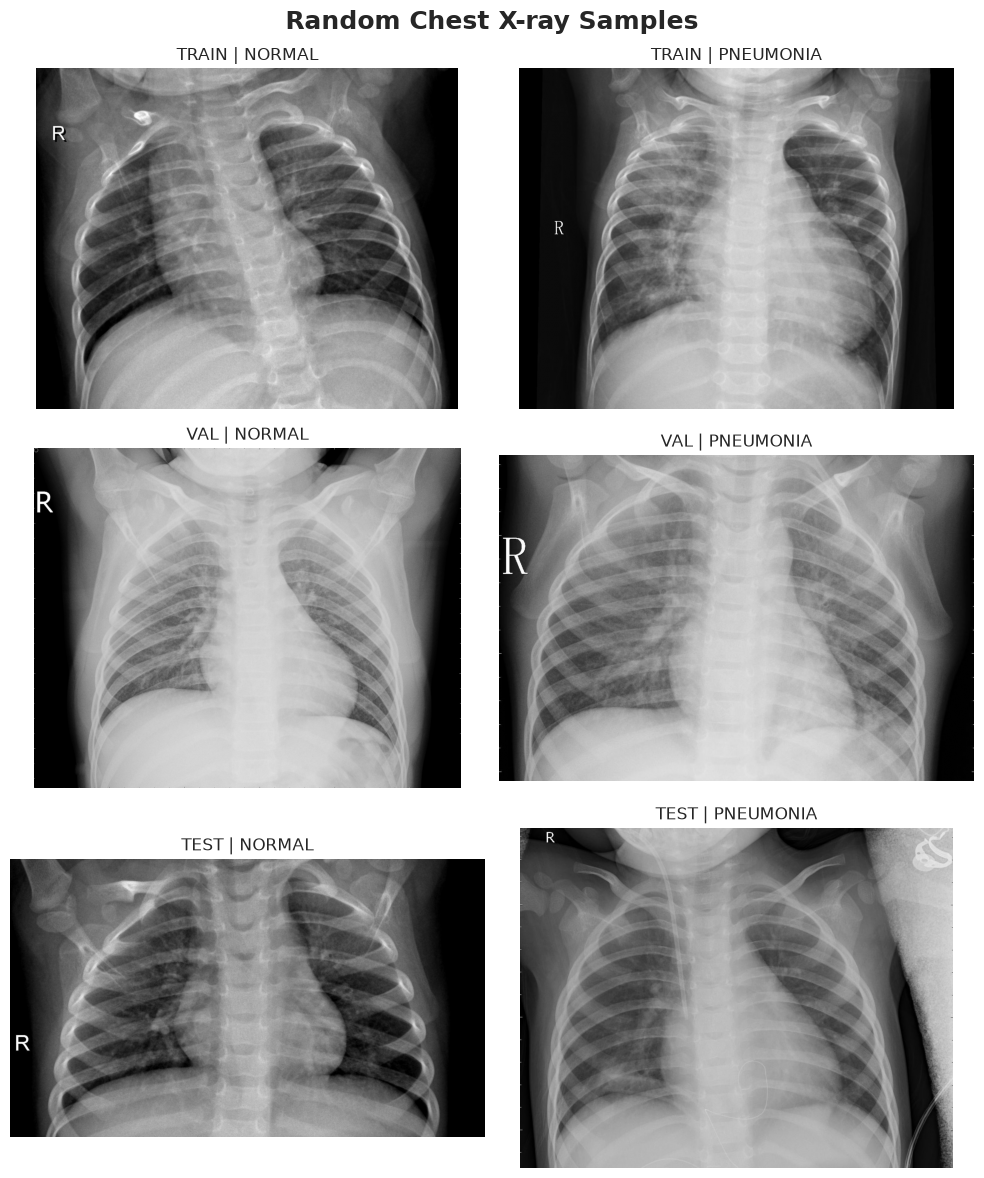

In [16]:
# ============================================================
# Display Random Sample Images
# ============================================================

import random
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]

fig, axes = plt.subplots(
    len(splits),
    len(classes),
    figsize=(10, 12)
)

for i, split in enumerate(splits):
    for j, cls in enumerate(classes):

        image_dir = DATASET_DIR / split / cls

        image_files = [
            img for img in image_dir.iterdir()
            if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]

        sample = random.choice(image_files)

        image = Image.open(sample)

        axes[i, j].imshow(image, cmap="gray")
        axes[i, j].set_title(f"{split.upper()} | {cls}")
        axes[i, j].axis("off")

plt.suptitle(
    "Random Chest X-ray Samples",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Image Resolution Analysis

Analyze the image dimensions across the original dataset to identify any inconsistencies before preprocessing.

In [17]:
# ============================================================
# Analyze Image Resolution
# ============================================================

from collections import Counter
from PIL import Image

image_sizes = []

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:

        folder = DATASET_DIR / split / cls

        for img_path in folder.iterdir():

            if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                continue

            with Image.open(img_path) as img:
                image_sizes.append(img.size)

size_counter = Counter(image_sizes)

print("=" * 60)
print("Top 10 Most Common Image Sizes")
print("=" * 60)

for size, count in size_counter.most_common(10):
    print(f"{size} : {count}")

Top 10 Most Common Image Sizes
(1072, 648) : 7
(1008, 704) : 7
(1216, 872) : 6
(1080, 728) : 6
(992, 592) : 6
(992, 608) : 6
(1304, 968) : 5
(1088, 712) : 5
(1008, 680) : 5
(976, 672) : 5


## Corrupted Image Detection

Check whether any unreadable or corrupted image files exist in the dataset.

In [18]:
# ============================================================
# Check Corrupted Images
# ============================================================

from PIL import Image

corrupted_images = []

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:

        folder = DATASET_DIR / split / cls

        for img_path in folder.iterdir():

            try:
                with Image.open(img_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(img_path)

print("=" * 60)

print(f"Corrupted Images Found : {len(corrupted_images)}")

if corrupted_images:
    print()

    for img in corrupted_images:
        print(img)

print("=" * 60)

Corrupted Images Found : 0


## Dataset Verification Summary

Summarize the verification results before proceeding to dataset preprocessing.

In [19]:
# ============================================================
# Verification Summary
# ============================================================

print("=" * 60)
print("DATASET VERIFICATION SUMMARY")
print("=" * 60)

print(f"Dataset Available      : {DATASET_DIR.exists()}")
print(f"Total Images           : {grand_total}")
print(f"Corrupted Images       : {len(corrupted_images)}")
print(f"Unique Image Sizes     : {len(size_counter)}")

print("\nStatus : Dataset verification completed successfully.")

print("=" * 60)

DATASET VERIFICATION SUMMARY
Dataset Available      : True
Total Images           : 5856
Corrupted Images       : 0
Unique Image Sizes     : 4803

Status : Dataset verification completed successfully.
